# Notebook 01 — Truth Table Reverse Engineering

Replication of §5.1 of Leandro (ALT 2009): recover symbolic Łukasiewicz formulas
**f1**, **f2**, **f6** from their truth sub-tables using three optimizers.

| Formula | Definition |
|---------|------------|
| f1 | x1 ⊗ (x3 ⟹ x6) |
| f2 | (x4 ⟹ x6) ⊗ (x6 ⟹ x2) |
| f6 | nested conjunctions/residua — hardest |

**Goals**
- Run extended trials (≥10 per method) to get reliable success-rate estimates.
- Compare LM / STE / Proximal convergence speed and crystallization quality.
- Extract symbolic formulas from every crystallized model.
- Record Δ(N) (representation error) and λ-similarity.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from luknn.benchmark.datasets import load_truth_table
from luknn.layers.lukasiewicz_linear import LukasiewiczNet
from luknn.optimizers import LMOptimizer, STEOptimizer, ProximalOptimizer
from luknn.benchmark.metrics import (
    compute_accuracy, compute_f1, compute_lambda_similarity,
    compute_delta_n, BenchmarkResult,
)
from luknn.extraction.extractor import extract_formula

print('luknn ready — torch', torch.__version__)

luknn ready — torch 2.12.0+cpu


## 1 · Experiment parameters

Adjust these cells to control the sweep.

In [2]:
# ── Sweep parameters ────────────────────────────────────────────────────────
FORMULAS      = ['f1', 'f2', 'f6']   # which formulas to test
N_VALUES      = 3                     # truth-table resolution (2=boolean, 3=3-valued …)
N_TRIALS      = 10                    # independent restarts per (method, formula)
MAX_ITER_LM   = 800                   # LM iterations (longer than default 400)
MAX_ITER_STE  = 8000                  # STE is gradient-based → needs more iters
MAX_ITER_PROX = 8000                  # Proximal similarly
TOL_MSE       = 2e-3                  # convergence threshold
HIDDEN_LAYERS = [4, 4]               # architecture
BASE_SEED     = 0
RESULTS_DIR   = '../results/truth_tables'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Optimizer hyper-parameters (tune here)
LM_PARAMS    = dict(mu_init=0.01, patience=80, crystallize_n=2, prune=True)
STE_PARAMS   = dict(lr=0.005, clip_grad=1.0)
PROX_PARAMS  = dict(lr=0.008, lambda_sparse=0.002, lambda_attract=0.08,
                    prox_threshold=0.0003, phase1_fraction=0.65)

print('Parameters set.')

Parameters set.


## 2 · Dataset preview

In [3]:
for formula in FORMULAS:
    ds = load_truth_table(formula=formula, n_values=N_VALUES)
    print(f'{formula}: {len(ds.X_train)+len(ds.X_test)} samples '
          f'({len(ds.X_train)} train / {len(ds.X_test)} test), '
          f'{ds.n_features} features')
    y_all = torch.cat([ds.y_train, ds.y_test])
    print(f'  y range: [{y_all.min():.3f}, {y_all.max():.3f}]  '
          f'mean={y_all.mean():.3f}')

f1: 729 samples (584 train / 145 test), 6 features
  y range: [0.000, 1.000]  mean=0.370
f2: 729 samples (584 train / 145 test), 6 features
  y range: [0.000, 1.000]  mean=0.556
f6: 729 samples (584 train / 145 test), 6 features
  y range: [0.000, 1.000]  mean=0.549


## 3 · Helper utilities

In [4]:
def build_optimizer(model, method, max_iter):
    if method == 'LM':
        return LMOptimizer(model, **LM_PARAMS), MAX_ITER_LM
    elif method == 'STE':
        return STEOptimizer(model, **STE_PARAMS), MAX_ITER_STE
    elif method == 'Proximal':
        return ProximalOptimizer(model, **PROX_PARAMS), MAX_ITER_PROX
    raise ValueError(method)

OPTIMIZER_MODE = {'LM': 'continuous', 'STE': 'ste', 'Proximal': 'clamp'}

def run_trial(method, formula, trial):
    seed = BASE_SEED + trial * 1000 + FORMULAS.index(formula) * 100
    torch.manual_seed(seed)
    np.random.seed(seed)

    ds = load_truth_table(formula=formula, n_values=N_VALUES, seed=seed)
    mode = OPTIMIZER_MODE[method]
    model = LukasiewiczNet(ds.n_features, HIDDEN_LAYERS, mode=mode)
    opt, max_iter = build_optimizer(model, method, None)

    result = opt.train(ds.X_train, ds.y_train,
                       tol_mse=TOL_MSE, max_iter=max_iter, verbose=False)

    with torch.no_grad():
        pred = model(ds.X_test)

    acc  = compute_accuracy(pred, ds.y_test)
    f1   = compute_f1(pred, ds.y_test)
    lam  = compute_lambda_similarity(model, ds.X_test, ds.y_test)
    dn   = compute_delta_n(model)
    crys = dn < 1e-3

    # Try formula extraction only on crystallized models
    formula_str = None
    if crys:
        try:
            er = extract_formula(model, ds.feature_names, n_values=N_VALUES)
            formula_str = er.formula
        except Exception as e:
            formula_str = f'[error: {e}]'

    return {
        'method': method, 'formula': formula, 'trial': trial,
        'mse': result.final_mse, 'accuracy': acc, 'f1': f1,
        'lambda': lam, 'delta_n': dn, 'crystallized': crys,
        'converged': result.converged, 'iterations': result.iterations,
        'iter_to_tol': next((i for i,m in enumerate(result.mse_history) if m < TOL_MSE), None),
        'extracted_formula': formula_str,
        'mse_history': result.mse_history,
        'model': model,
        'dataset': ds,
    }

print('Helpers ready.')

Helpers ready.


## 4 · Full sweep

Run all (formula × method × trial) combinations.  
**Expected runtime:** ~5–20 min on CPU depending on hardware.

In [5]:
import time

all_rows = []
all_records = []  # includes model + mse_history for later use

for formula in FORMULAS:
    for method in ['LM', 'STE', 'Proximal']:
        successes = 0
        t_start = time.time()
        for trial in range(N_TRIALS):
            rec = run_trial(method, formula, trial)
            all_records.append(rec)
            row = {k: v for k, v in rec.items() if k not in ('mse_history', 'model', 'dataset')}
            all_rows.append(row)
            if rec['crystallized']:
                successes += 1
        elapsed = time.time() - t_start
        print(f'{formula}/{method}: {successes}/{N_TRIALS} crystallized  ({elapsed:.1f}s)')

df = pd.DataFrame(all_rows)
df.to_csv(f'{RESULTS_DIR}/full_sweep.csv', index=False)
print('\nSweep complete. Results saved.')

f1/LM: 2/10 crystallized  (2.7s)
f1/STE: 10/10 crystallized  (12.1s)
f1/Proximal: 10/10 crystallized  (14.7s)
f2/LM: 3/10 crystallized  (2.5s)
f2/STE: 10/10 crystallized  (13.5s)
f2/Proximal: 10/10 crystallized  (20.1s)
f6/LM: 0/10 crystallized  (5.7s)
f6/STE: 10/10 crystallized  (12.5s)
f6/Proximal: 10/10 crystallized  (62.6s)

Sweep complete. Results saved.


## 5 · Summary statistics

In [6]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

agg = df.groupby(['formula', 'method']).agg(
    mse_mean=('mse', 'mean'),
    mse_std=('mse', 'std'),
    acc_mean=('accuracy', 'mean'),
    f1_mean=('f1', 'mean'),
    lambda_mean=('lambda', 'mean'),
    delta_n_mean=('delta_n', 'mean'),
    crys_rate=('crystallized', 'mean'),
    conv_rate=('converged', 'mean'),
    iter_mean=('iterations', 'mean'),
).round(4)

print('=== Aggregate results (mean over', N_TRIALS, 'trials) ===')
agg

=== Aggregate results (mean over 10 trials) ===


mse_mean  mse_std  acc_mean  f1_mean  lambda_mean  \
formula method                                                        
f1      LM          0.1410   0.1562    0.6138   0.4777       0.8175   
        Proximal    0.2110   0.1120    0.6021   0.1873       0.7650   
        STE         0.2376   0.1962    0.5869   0.3975       0.7614   
f2      LM          0.1852   0.1817    0.6097   0.6313       0.7998   
        Proximal    0.3917   0.1444    0.3655   0.1860       0.6282   
        STE         0.2360   0.1035    0.5317   0.6507       0.7380   
f6      LM          0.2150   0.1387    0.3448   0.5613       0.7273   
        Proximal    0.2700   0.1225    0.5007   0.5045       0.7087   
        STE         0.3716   0.1056    0.3648   0.3380       0.6269   

                  delta_n_mean  crys_rate  conv_rate  iter_mean  
formula method                                                   
f1      LM             15.9471     0.2000     0.2000   443.0000  
        Proximal        0.0000     1.0000     0.0000   704.1000  
        STE             0.0000     1.0000     0.0000   666.3000  
f2      LM             14.5291     0.3000     0.4000   357.2000  
        Proximal        0.0000     1.0000     0.1000   964.6000  
        STE             0.0000     1.0000     0.0000   811.6000  
f6      LM             21.3694     0.0000     0.0000   275.4000  
        Proximal        0.0000     1.0000     0.0000  3627.4000  
        STE             0.0000     1.0000     0.0000   621.6000

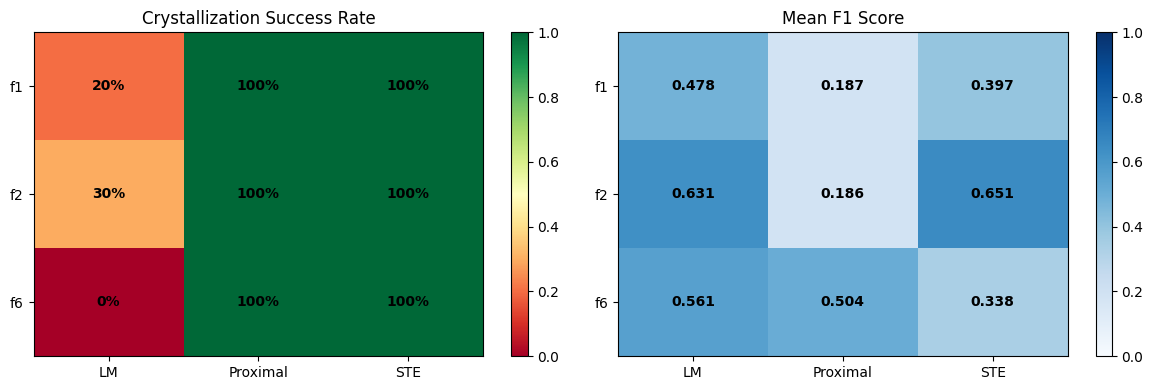

In [7]:
# Crystallization success rate heatmap
crys_pivot = df.pivot_table(values='crystallized', index='formula',
                             columns='method', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: crystallization rate
im = axes[0].imshow(crys_pivot.values, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks(range(len(crys_pivot.columns)))
axes[0].set_xticklabels(crys_pivot.columns)
axes[0].set_yticks(range(len(crys_pivot.index)))
axes[0].set_yticklabels(crys_pivot.index)
for i in range(len(crys_pivot.index)):
    for j in range(len(crys_pivot.columns)):
        axes[0].text(j, i, f'{crys_pivot.values[i,j]:.0%}',
                     ha='center', va='center', fontweight='bold')
axes[0].set_title('Crystallization Success Rate')
plt.colorbar(im, ax=axes[0])

# Right: mean F1
f1_pivot = df.pivot_table(values='f1', index='formula', columns='method', aggfunc='mean')
im2 = axes[1].imshow(f1_pivot.values, vmin=0, vmax=1, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(f1_pivot.columns)))
axes[1].set_xticklabels(f1_pivot.columns)
axes[1].set_yticks(range(len(f1_pivot.index)))
axes[1].set_yticklabels(f1_pivot.index)
for i in range(len(f1_pivot.index)):
    for j in range(len(f1_pivot.columns)):
        axes[1].text(j, i, f'{f1_pivot.values[i,j]:.3f}',
                     ha='center', va='center', fontweight='bold')
axes[1].set_title('Mean F1 Score')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/heatmaps.png', dpi=150)
plt.show()

## 6 · Learning curves

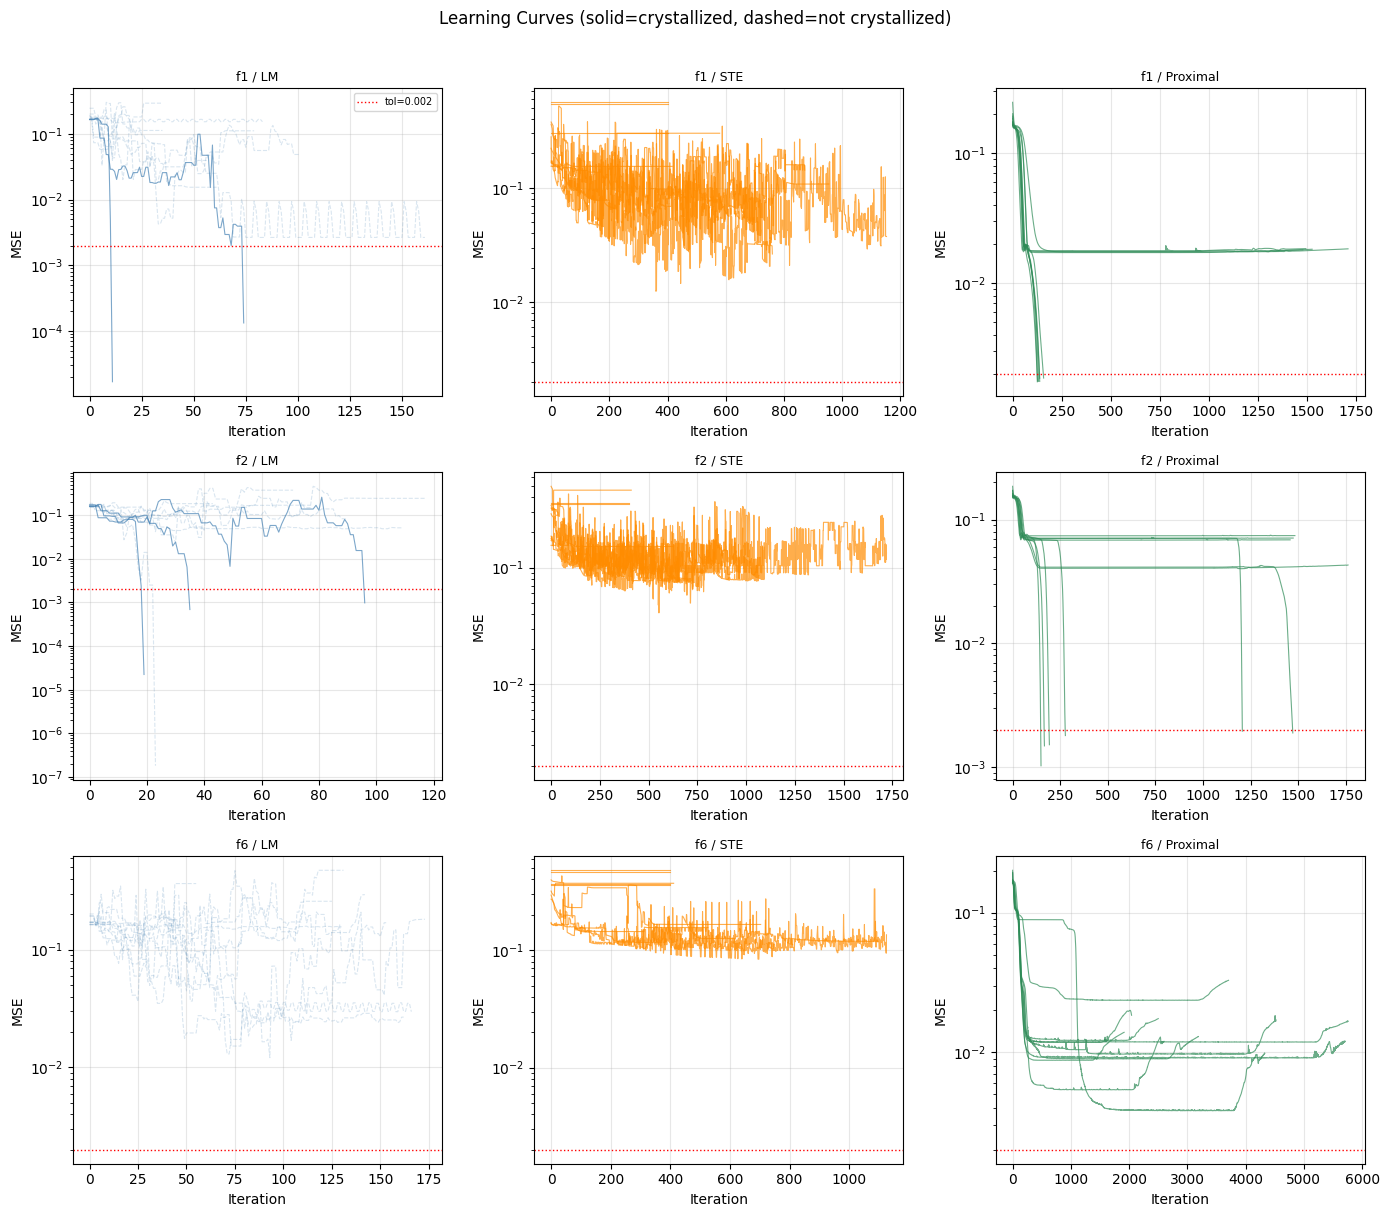

In [8]:
def plot_learning_curves(formula, method, ax, color):
    recs = [r for r in all_records if r['formula'] == formula and r['method'] == method]
    for r in recs:
        hist = r['mse_history']
        if hist:
            alpha = 0.7 if r['crystallized'] else 0.2
            ls = '-' if r['crystallized'] else '--'
            ax.semilogy(hist, color=color, alpha=alpha, linewidth=0.8, linestyle=ls)
    ax.axhline(TOL_MSE, color='red', linestyle=':', linewidth=1, label=f'tol={TOL_MSE}')
    ax.set_title(f'{formula} / {method}', fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('MSE')
    ax.grid(True, alpha=0.3)

METHODS = ['LM', 'STE', 'Proximal']
COLORS  = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(len(FORMULAS), len(METHODS),
                          figsize=(14, 4 * len(FORMULAS)), sharex=False)

for i, formula in enumerate(FORMULAS):
    for j, (method, color) in enumerate(zip(METHODS, COLORS)):
        ax = axes[i][j] if len(FORMULAS) > 1 else axes[j]
        plot_learning_curves(formula, method, ax, color)

axes[0][0].legend(fontsize=7)
plt.suptitle('Learning Curves (solid=crystallized, dashed=not crystallized)', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Representation error Δ(N) distribution

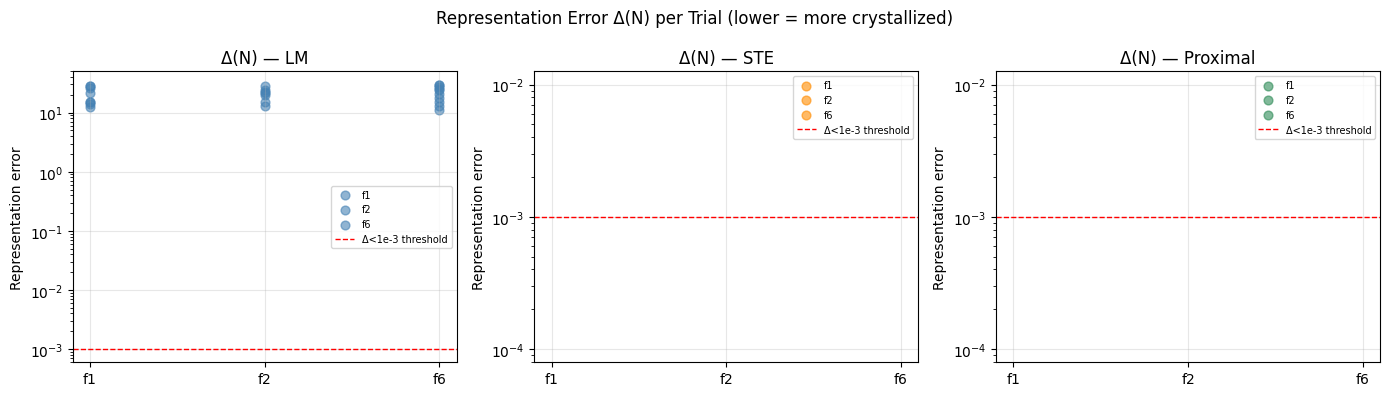

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for j, (method, color) in enumerate(zip(METHODS, COLORS)):
    ax = axes[j]
    for formula in FORMULAS:
        vals = df[(df['method'] == method) & (df['formula'] == formula)]['delta_n']
        ax.scatter([formula] * len(vals), vals.values,
                   color=color, alpha=0.6, s=40, label=formula)
    ax.axhline(1e-3, color='red', linestyle='--', linewidth=1, label='Δ<1e-3 threshold')
    ax.set_yscale('log')
    ax.set_title(f'Δ(N) — {method}')
    ax.set_ylabel('Representation error')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle('Representation Error Δ(N) per Trial (lower = more crystallized)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/delta_n.png', dpi=150)
plt.show()

## 8 · Formula extraction from crystallized models

In [10]:
GROUND_TRUTH = {
    'f1': 'x1 ⊗ (x3 ⟹ x6)',
    'f2': '(x4 ⟹ x6) ⊗ (x6 ⟹ x2)',
    'f6': '((((x4⊗x5)⟹x6) ⊗ ((x1⊗x5)⟹x2)) ⊗ ((x1⊗x2)⟹x3)) ⊗ (x6⟹x4)',
}

print('=== Extracted formulas from crystallized models ===')
print()

for formula in FORMULAS:
    print(f'── {formula} (ground truth: {GROUND_TRUTH[formula]}) ──')
    crys_recs = [r for r in all_records
                 if r['formula'] == formula and r['crystallized']
                 and r['extracted_formula'] is not None]
    if not crys_recs:
        print('  No crystallized models found.')
    for r in crys_recs[:3]:  # show up to 3 per formula
        print(f'  [{r["method"]} trial {r["trial"]}]  MSE={r["mse"]:.5f}  '
              f'λ={r["lambda"]:.4f}  Δ(N)={r["delta_n"]:.6f}')
        print(f'  Formula: {r["extracted_formula"]}')
    print()

=== Extracted formulas from crystallized models ===

── f1 (ground truth: x1 ⊗ (x3 ⟹ x6)) ──
  [LM trial 0]  MSE=0.00000  λ=1.0000  Δ(N)=0.000000
  Formula: ¬x3 ⊗ ¬x6 ⊕ ¬x1
  [LM trial 3]  MSE=0.50214  λ=0.5545  Δ(N)=0.000000
  Formula: ¬ψ_0([0, 1], ψ_0([1, -1, 1]))
  [STE trial 0]  MSE=0.54495  λ=0.5070  Δ(N)=0.000000
  Formula: ψ_2([0, 0, 1], ψ_-1([1, 1]))

── f2 (ground truth: (x4 ⟹ x6) ⊗ (x6 ⟹ x2)) ──
  [LM trial 0]  MSE=0.16824  λ=0.8159  Δ(N)=0.000000
  Formula: ¬¬¬x4 ⊕ x6 ⊗ ψ_4([0, 0, 0, 0, 0], ψ_-1([0, -1])) ⊗ ¬x2 ⊕ ¬x6 ⊗ ¬¬¬x4 ⊕ x6
  [LM trial 4]  MSE=0.00000  λ=1.0000  Δ(N)=0.000000
  Formula: ψ_0([0, 0, -1], ψ_0([-1, 0])) ⊕ ¬x4 ⊕ x6 ⊗ x2 ⊕ ¬x6
  [LM trial 6]  MSE=0.00000  λ=1.0000  Δ(N)=0.000000
  Formula: ¬x4 ⊗ ¬x6 ⊕ ¬x2 ⊕ ¬x6

── f6 (ground truth: ((((x4⊗x5)⟹x6) ⊗ ((x1⊗x5)⟹x2)) ⊗ ((x1⊗x2)⟹x3)) ⊗ (x6⟹x4)) ──
  [STE trial 0]  MSE=0.46404  λ=0.5700  Δ(N)=0.000000
  Formula: ψ_0([0, 0, 0], ψ_0([0, -1]))
  [STE trial 1]  MSE=0.36430  λ=0.6300  Δ(N)=0.000000
  Formula: ψ_2([1, 0

## 9 · Deep dive: best crystallized model per formula

In [11]:
print('=== Weight matrices of best crystallized models ===\n')

for formula in FORMULAS:
    crys_recs = [
        r for r in all_records if r['formula'] == formula and r['crystallized']
    ]
    if not crys_recs:
        print(f'{formula}: no crystallized model found.\n')
        continue
    best = min(crys_recs, key=lambda r: r['mse'])
    model = best['model']
    ds = best['dataset']
    print(f'{formula} — best: {best["method"]} trial {best["trial"]}  '
          f'MSE={best["mse"]:.5f}  F1={best["f1"]:.4f}')

    for layer_idx, (W, b) in enumerate(model.weight_matrix_repr()):
        W_int = W.round().int()
        b_int = b.round().int()
        print(f'  Layer {layer_idx}  W={W_int.tolist()}  b={b_int.tolist()}')

    if best['extracted_formula']:
        print(f'  Formula: {best["extracted_formula"]}')

    # Layer-by-layer formula breakdown
    try:
        er = extract_formula(model, ds.feature_names, n_values=N_VALUES)
        print('  Layer formulas:')
        for li, layer in enumerate(er.layer_formulas):
            for ni, sym in enumerate(layer):
                print(f'    L{li}N{ni}: {sym}')
    except Exception as e:
        print(f'  Extraction error: {e}')
    print()

=== Weight matrices of best crystallized models ===

f1 — best: LM trial 0  MSE=0.00000  F1=0.4946
  Layer 0  W=[[1, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, -1], [0, 0, 1, 0, 0, -1], [-1, 0, 0, 0, 0, 0]]  b=[1, 1, 0, 1]
  Layer 1  W=[[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, -1, -1], [0, 0, 1, 1]]  b=[0, 0, 0, 0]
  Layer 2  W=[[0, 0, 0, -1]]  b=[1]
  Formula: ¬x3 ⊗ ¬x6 ⊕ ¬x1
  Layer formulas:
    L0N0: ψ_2([1, 0, 0, 0, 0], ψ_-1([0, 0]))
    L0N1: x3 ⊕ ¬x6
    L0N2: x3 ⊗ ¬x6
    L0N3: ¬x1
    L1N0: 0
    L1N1: 0
    L1N2: ψ_0([0, 0, -1], ψ_0([-1, -1]))
    L1N3: x3 ⊗ ¬x6 ⊕ ¬x1
    L2N0: ¬x3 ⊗ ¬x6 ⊕ ¬x1

f2 — best: LM trial 4  MSE=0.00000  F1=0.6667
  Layer 0  W=[[0, 0, 0, -1, 0, 1], [0, -1, 0, 0, 0, -1], [0, -1, 0, 0, 0, 1], [0, 1, 0, 0, 0, -1]]  b=[1, 1, 1, 1]
  Layer 1  W=[[0, 0, -1, 0], [0, 0, 0, 1], [1, 0, 0, 1], [-1, 0, 0, 1]]  b=[0, 1, -1, 0]
  Layer 2  W=[[1, 0, 1, 0]]  b=[0]
  Formula: ψ_0([0, 0, -1], ψ_0([-1, 0])) ⊕ ¬x4 ⊕ x6 ⊗ x2 ⊕ ¬x6
  Layer formulas:
    L0N0: ¬x4 ⊕ x6
    L0N1: ¬x2 ⊗ ¬x6


## 10 · Convergence speed: iterations to tolerance

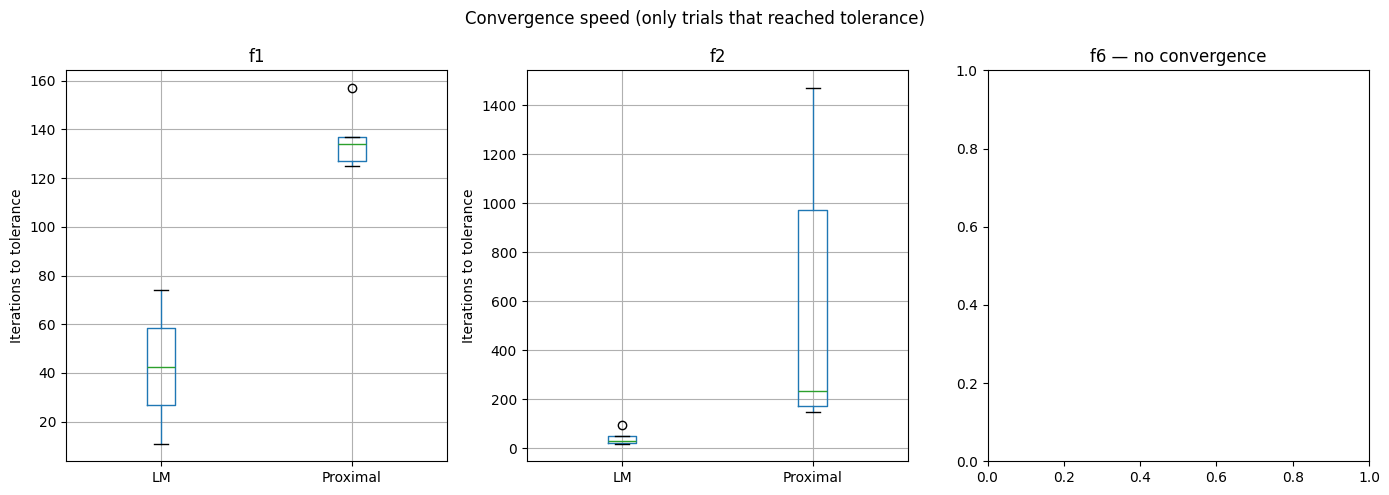

                     mean      std  min   max
formula method                               
f1      LM        42.0000  45.0000   11    74
        Proximal 136.0000  12.0000  125   157
f2      LM        43.0000  36.0000   19    96
        Proximal 576.0000 598.0000  148  1471


In [12]:
df_conv = df[df['iter_to_tol'].notna()].copy()
df_conv['iter_to_tol'] = df_conv['iter_to_tol'].astype(int)

if df_conv.empty:
    print('No trials reached tolerance within budget.')
else:
    fig, axes = plt.subplots(1, len(FORMULAS), figsize=(14, 5), sharey=False)
    for i, formula in enumerate(FORMULAS):
        ax = axes[i] if len(FORMULAS) > 1 else axes
        sub = df_conv[df_conv['formula'] == formula]
        if sub.empty:
            ax.set_title(f'{formula} — no convergence')
            continue
        sub.boxplot(column='iter_to_tol', by='method', ax=ax)
        ax.set_title(f'{formula}')
        ax.set_xlabel('')
        ax.set_ylabel('Iterations to tolerance')
    plt.suptitle('Convergence speed (only trials that reached tolerance)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/convergence_speed.png', dpi=150)
    plt.show()

    print(df_conv.groupby(['formula','method'])['iter_to_tol']
          .agg(['mean','std','min','max']).round(0))

## 11 · Export full results table

In [13]:
cols = ['formula','method','trial','mse','accuracy','f1','lambda','delta_n',
        'crystallized','converged','iterations','iter_to_tol','extracted_formula']
display_df = df[cols].copy()
display_df = display_df.sort_values(['formula','method','trial'])
display_df.to_csv(f'{RESULTS_DIR}/all_trials.csv', index=False)
print('Saved to', f'{RESULTS_DIR}/all_trials.csv')
display_df.head(30)

Saved to ../results/truth_tables/all_trials.csv


,formula,method,trial,mse,accuracy,f1,lambda,delta_n,crystallized,converged,iterations,iter_to_tol,extracted_formula
0,f1,LM,0,0.0000,1.0000,0.4946,1.0000,0.0000,True,True,11,11.0000,¬x3 ⊗ ¬x6 ⊕ ¬x1
1,f1,LM,1,0.0154,0.8759,0.5714,0.9398,15.0002,False,False,800,NaN,NaN
2,f1,LM,2,0.1126,0.6414,0.7778,0.8272,15.1245,False,False,800,NaN,NaN
3,f1,LM,3,0.5021,0.2138,0.3125,0.5545,0.0000,True,True,74,74.0000,"¬ψ_0([0, 1], ψ_0([1, -1, 1]))"
4,f1,LM,4,0.1717,0.5793,0.5505,0.7615,27.7540,False,False,800,NaN,NaN
5,f1,LM,5,0.0027,0.9517,0.8889,0.9829,25.6985,False,False,161,NaN,NaN
6,f1,LM,6,0.2928,0.5034,0.0000,0.6891,27.8995,False,False,800,NaN,NaN
7,f1,LM,7,0.1113,0.7241,0.6078,0.8475,14.0185,False,False,800,NaN,NaN
8,f1,LM,8,0.1529,0.0276,0.0000,0.6864,12.3122,False,False,83,NaN,NaN
9,f1,LM,9,0.0486,0.6207,0.5736,0.8861,21.6634,False,False,101,NaN,NaN
